# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini-Project: Simple Analytics using Pyspark

## Problem Statement

Perform simple analytics with Pyspark on the real estate valuation dataset and predict the house price per unit area

## Learning Objectives

At the end of the mini-project, you will be able to :

* analyze the data using pyspark
* derive the insights and visualize the data
* implement linear regression and evaluate using pyspark

### Dataset

The dataset chosen for this mini-project is **Real Estate Valuation dataset**. The data was collected from the historical market of real estate within Sindian District of New Taipei City, the timespan across 2012 August to 2013 July. In the dataset, the response variable (house price per unit area) is calculated in a local unit which is approximately $10000 New Taipei Dollar per 3.3 squared meters. For the collection of regressor data, the transaction dates are transformed into a format such that 2013.250 = 2013 March, 2013.500 = 2013 June etc. The house age was collected in years and the distance to MRT stations is measured in meters.

**Reference:**
The original owner of this Real Estate Valuation dataset is professor I-Cheng Yeh from TamKang University (Department of Civil Engineering). Prof. Yeh donated this dataset to UCI machine learning repository on 18th August 2018. The dataset can be accessed at https://archive.ics.uci.edu/ml/datasets/Real+estate+valuation+data+set#[1].

## Grading = 10 Points

#### Install Pyspark

In [1]:
#@title Install pyspark and Download the data
!pip -qq install pyspark
!pip -qq install handyspark
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/RealEstate.csv
print("Packages installed and dataset downloaded successfully!")

     |████████████████████████████████| 281.3 MB 44 kB/s 
     |████████████████████████████████| 199 kB 54.4 MB/s 
Packages installed and dataset downloaded successfully!


#### Import required packages

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.feature import MinMaxScaler
from handyspark import *
import seaborn as sns
from matplotlib import pyplot as plt

### Data Loading (1 point)

#### Start a Spark Session

Spark session is a combined entry point of a Spark application, which came into implementation from Spark 2.0. It provides a way to interact with various spark’s functionality with a lesser number of constructs.

In [3]:
spark = SparkSession.builder.appName('RealEstate').getOrCreate()

#### Load the data and infer the schema

To load the dataset use the `read.csv` with `inferSchema` and `header` as parameters.

In [4]:
csv_path = "/content/RealEstate.csv"
df = spark.read.csv(csv_path, header=True, inferSchema = True)           # creating spark data frame

In [5]:
# Print the data types 
df.dtypes

[('No', 'int'),
 ('X1 transaction date', 'double'),
 ('X2 house age', 'double'),
 ('X3 distance to the nearest MRT station', 'double'),
 ('X4 number of convenience stores', 'int'),
 ('X5 latitude', 'double'),
 ('X6 longitude', 'double'),
 ('Y house price of unit area', 'double')]

In [6]:
# Print the Schema of the DataFrame
df.printSchema()

root
 |-- No: integer (nullable = true)
 |-- X1 transaction date: double (nullable = true)
 |-- X2 house age: double (nullable = true)
 |-- X3 distance to the nearest MRT station: double (nullable = true)
 |-- X4 number of convenience stores: integer (nullable = true)
 |-- X5 latitude: double (nullable = true)
 |-- X6 longitude: double (nullable = true)
 |-- Y house price of unit area: double (nullable = true)



In [7]:
df.show(5)

+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+
| No|X1 transaction date|X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|X5 latitude|X6 longitude|Y house price of unit area|
+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+
|  1|           2012.917|        32.0|                              84.87882|                             10|   24.98298|   121.54024|                      37.9|
|  2|           2012.917|        19.5|                              306.5947|                              9|   24.98034|   121.53951|                      42.2|
|  3|           2013.583|        13.3|                              561.9845|                              5|   24.98746|   121.54391|                      47.3|
|  4|             2013.5|   

In [8]:
df.count()

414

In [9]:
df.columns

['No',
 'X1 transaction date',
 'X2 house age',
 'X3 distance to the nearest MRT station',
 'X4 number of convenience stores',
 'X5 latitude',
 'X6 longitude',
 'Y house price of unit area']

In [10]:
df.describe().show()

+-------+-----------------+-------------------+------------------+--------------------------------------+-------------------------------+--------------------+--------------------+--------------------------+
|summary|               No|X1 transaction date|      X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|         X5 latitude|        X6 longitude|Y house price of unit area|
+-------+-----------------+-------------------+------------------+--------------------------------------+-------------------------------+--------------------+--------------------+--------------------------+
|  count|              414|                414|               414|                                   414|                            414|                 414|                 414|                       414|
|   mean|            207.5| 2013.1489710144933| 17.71256038647343|                    1083.8856889130436|              4.094202898550725|  24.969030072463745|  121.53336108

#### Fetch the data using handyspark

* Create a HandyFrame using handyspark `toHandy()` function

* using an instance of `cols` from your HandyFrame, you can retrieve values for given columns in the top N rows

Hint: [toHandy()](https://dvgodoy.github.io/handyspark/includeme.html)

In [11]:
hdf = df.toHandy()

/usr/local/lib/python3.7/dist-packages/pyspark/sql/dataframe.py:149: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  "DataFrame.sql_ctx is an internal property, and will be removed "
/usr/local/lib/python3.7/dist-packages/pyspark/sql/dataframe.py:127: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


In [12]:
hdf

HandyFrame[No: int, X1 transaction date: double, X2 house age: double, X3 distance to the nearest MRT station: double, X4 number of convenience stores: int, X5 latitude: double, X6 longitude: double, Y house price of unit area: double]

In [13]:
hdf.cols['X2 house age'][:10]

/usr/local/lib/python3.7/dist-packages/pyspark/sql/dataframe.py:149: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  "DataFrame.sql_ctx is an internal property, and will be removed "
/usr/local/lib/python3.7/dist-packages/pyspark/sql/dataframe.py:127: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


0    32.0
1    19.5
2    13.3
3    13.3
4     5.0
5     7.1
6    34.5
7    20.3
8    31.7
9    17.9
Name: X2 house age, dtype: float64

### Deriving the insights (2 points)

#### show the no. of records per month

Hint: Apply [groupby](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.sql.GroupedData.agg.html?highlight=agg#pyspark.sql.GroupedData.agg) on transaction date and count the records using aggregation `agg()`

In [63]:
from pyspark.sql import functions as F
DF = df.groupby('X1 transaction date').agg(F.count("X1 transaction date"))
DF.show()

+-------------------+--------------------------+
|X1 transaction date|count(X1 transaction date)|
+-------------------+--------------------------+
|            2012.75|                        27|
|           2013.333|                        29|
|           2013.083|                        46|
|           2012.833|                        31|
|             2013.5|                        47|
|           2013.583|                        23|
|           2013.417|                        58|
|           2013.167|                        25|
|            2013.25|                        32|
|             2013.0|                        28|
|           2012.917|                        38|
|           2012.667|                        30|
+-------------------+--------------------------+



#### how much is the increase in the average house price in 2012 to 2013

Hint: Apply [filter](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.sql.DataFrame.filter.html) on the transaction date and aggregate the house price using mean

In [129]:
from pyspark.sql.functions import col, min
df.filter(col('X1 transaction date')>=2013).agg(avg('Y house price of unit area')).show() # 2013 Answer is 38.713194444444454

+-------------------------------+
|avg(Y house price of unit area)|
+-------------------------------+
|             38.713194444444454|
+-------------------------------+



In [130]:
from pyspark.sql.functions import col, min
df.filter(col('X1 transaction date')<2013).agg(avg('Y house price of unit area')).show() # 2012 Answer is 36.304761904761904

+-------------------------------+
|avg(Y house price of unit area)|
+-------------------------------+
|             36.304761904761904|
+-------------------------------+



In [131]:
increase = 38.713194444444454 - 36.304761904761904
increase # answer is 2.4084325396825506

2.4084325396825506

#### Find the count of houses with no convenience store and show the top 10 records

In [15]:
df.filter(df['X4 number of convenience stores'] == 0).show(10)

+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+
| No|X1 transaction date|X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|X5 latitude|X6 longitude|Y house price of unit area|
+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+
| 31|             2013.5|        25.9|                               4519.69|                              0|   24.94826|   121.49587|                      22.1|
| 36|             2013.5|        13.9|                              4079.418|                              0|   25.01459|   121.51816|                      27.3|
| 41|             2013.0|        13.6|                              4082.015|                              0|   24.94155|   121.50381|                      15.9|
| 42|             2013.5|   

#### Compare the maximum price of houses *with convenient store* and *without convenience store*

In [16]:
from pyspark.sql.functions import col, min
df.filter(col('X4 number of convenience stores')==0).agg(max('Y house price of unit area')).show() # Answer is 55.3

+-------------------------------+
|max(Y house price of unit area)|
+-------------------------------+
|                           55.3|
+-------------------------------+



In [17]:
df.filter(col('X4 number of convenience stores')>0).agg(max('Y house price of unit area')).show() # Answer is 117.5

+-------------------------------+
|max(Y house price of unit area)|
+-------------------------------+
|                          117.5|
+-------------------------------+



#### Decode the transaction date

* create a year column separately by removing the decimal places from transaction date column

    Hint: `withColumn()`

* create a month column separately based on the decimal places from the transaction date column
 
 **Hints:** multiply decimal place number with 12 and apply round off, perform below steps
     
     - use `udf()` from pyspark
     - subtracting `transaction date` from `int(transaction date)` will give the decimal place number
     - multiply the result with 12 and roundoff

To know more about udf(), click [here](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.sql.functions.udf.html?highlight=udf#pyspark.sql.functions.udf)

In [68]:
df.withColumn("Year",col("X1 transaction date").cast("Integer")).show(5)

+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+----+
| No|X1 transaction date|X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|X5 latitude|X6 longitude|Y house price of unit area|Year|
+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+----+
|  1|           2012.917|        32.0|                              84.87882|                             10|   24.98298|   121.54024|                      37.9|2012|
|  2|           2012.917|        19.5|                              306.5947|                              9|   24.98034|   121.53951|                      42.2|2012|
|  3|           2013.583|        13.3|                              561.9845|                              5|   24.98746|   121.54391|                      47.3|2013

In [119]:
@udf(returnType=IntegerType())
def extractMonth(transac_dt):
  month = float(transac_dt) - int(transac_dt)
  month  = round(month*12)
  print(month)
  return int(month)

In [121]:
from pyspark.sql.types import ArrayType
from pyspark.sql.types import IntegerType
from pyspark.sql.types import FloatType

#convertUdf = udf(lambda z: extractMonth(z))

In [124]:
# Bit stuck - this throws error
new_df = df.withColumn("Month", extractMonth(col("X1 transaction date"))).show()

PythonException: ignored

### Data Visualization (2 points)

#### Select the continuous variables from the data and visualize using histogram

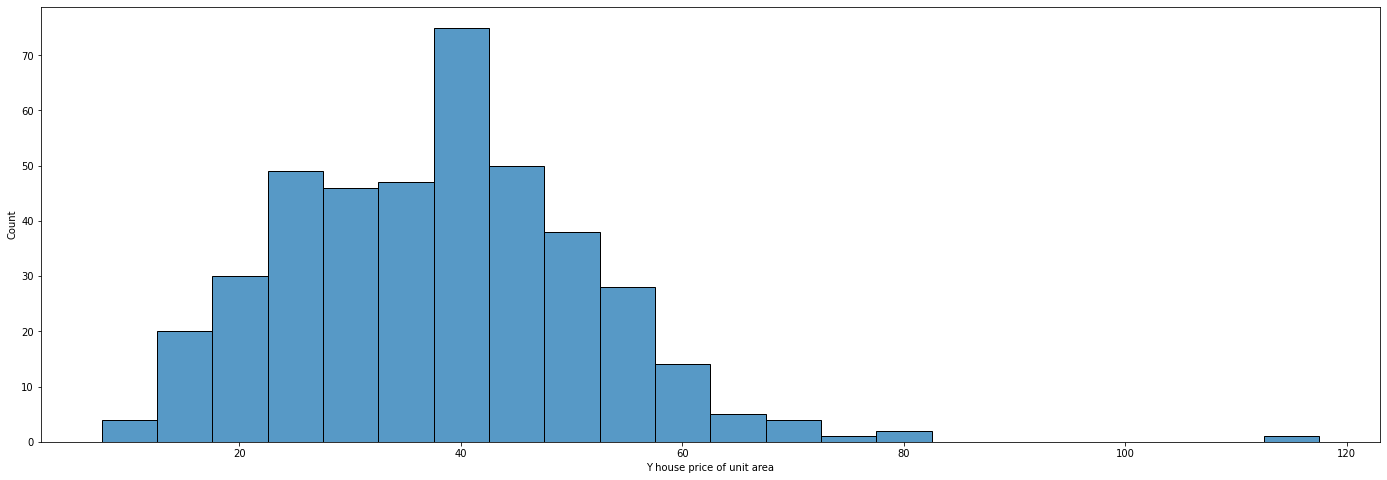

In [59]:
plt.figure(figsize= (20,10))
df_p = df.toPandas()
sns.histplot(data=df_p, x=df_p['Y house price of unit area'])

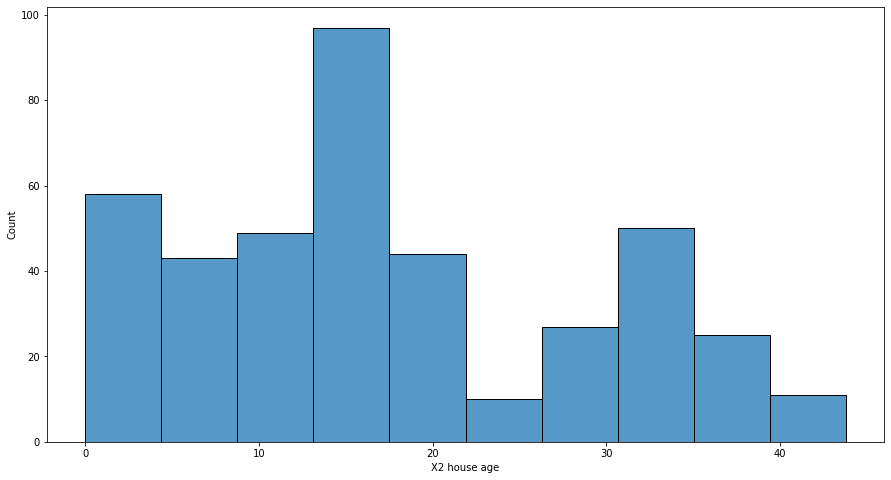

In [69]:
plt.figure(figsize= (15,8))
df_p = df.toPandas()
sns.histplot(data=df_p, x=df_p['X2 house age'])

#### Visualize the transaction date using the countplot

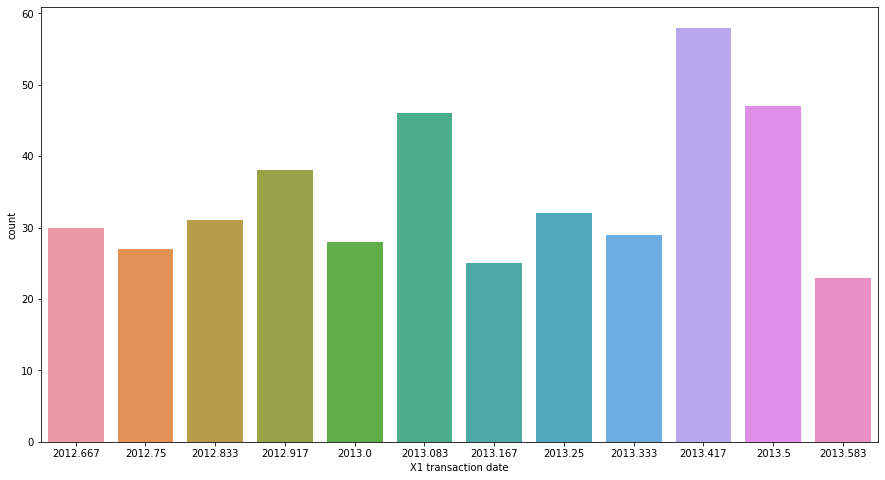

In [128]:
plt.figure(figsize= (15,8))
sns.countplot(x ='X1 transaction date', data = df_p)

#### visualize number of convenience stores with appropriate plot.

In [21]:
DF = df.groupby('X4 number of convenience stores').count().sort("count", ascending= False)
DF.show(8)

+-------------------------------+-----+
|X4 number of convenience stores|count|
+-------------------------------+-----+
|                              5|   67|
|                              0|   67|
|                              3|   46|
|                              1|   46|
|                              6|   37|
|                              7|   31|
|                              4|   31|
|                              8|   30|
+-------------------------------+-----+
only showing top 8 rows



/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


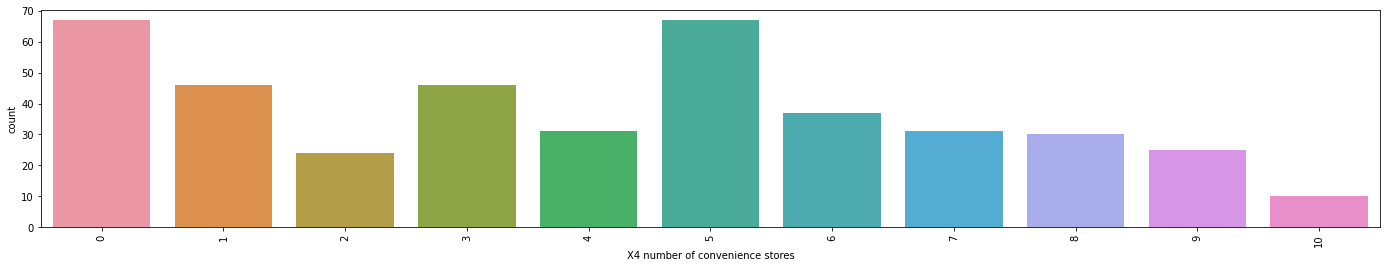

In [22]:
plt.figure(figsize= (24,4))
x = DF.toPandas()['X4 number of convenience stores']
y = DF.toPandas()['count']
sns.barplot(x, y)
plt.xticks(rotation= 90)
plt.show()

#### visualize the geographical distribution of the house prices of unit area

With:

* x-axis = X6 longitude
* y-axis = X5 latitude
* datapoints = Y house price of unit area
* parameters including size `s` and color map `cmap`

In [42]:
df_create = df.toDF("No","X1 transaction date", "X2 house age", "X3 distance to the nearest MRT station","X4 number of convenience stores","X5 latitude","X6 longitude",'Y house price of unit area')
pandas_df = df_create.toPandas()
pandas_df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


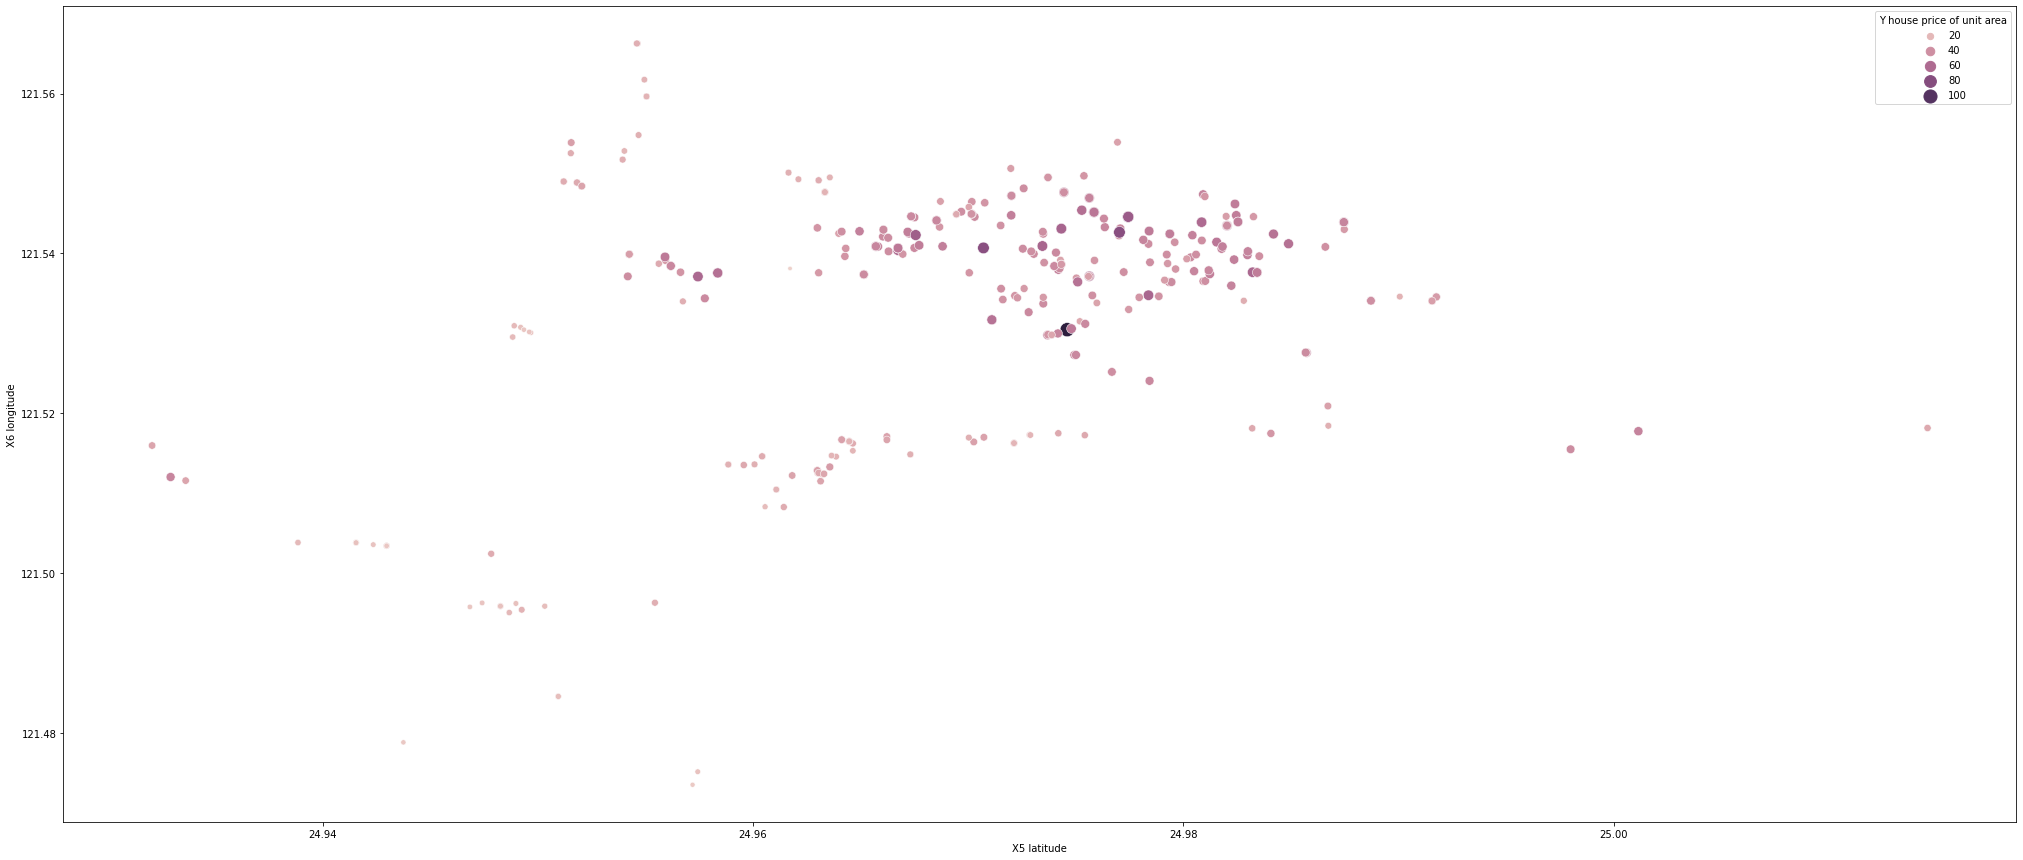

In [54]:
plt.figure(figsize=(35, 15))
sns.scatterplot(x=pandas_df["X5 latitude"], y=pandas_df["X6 longitude"],hue=pandas_df["Y house price of unit area"],sizes=(20, 200),size=pandas_df["Y house price of unit area"])

### Feature Scaling (1 point)

#### Identify the outliers

Use the pairplot or boxplot to identify the outliers

   **Hint:** `sns.pairplot`

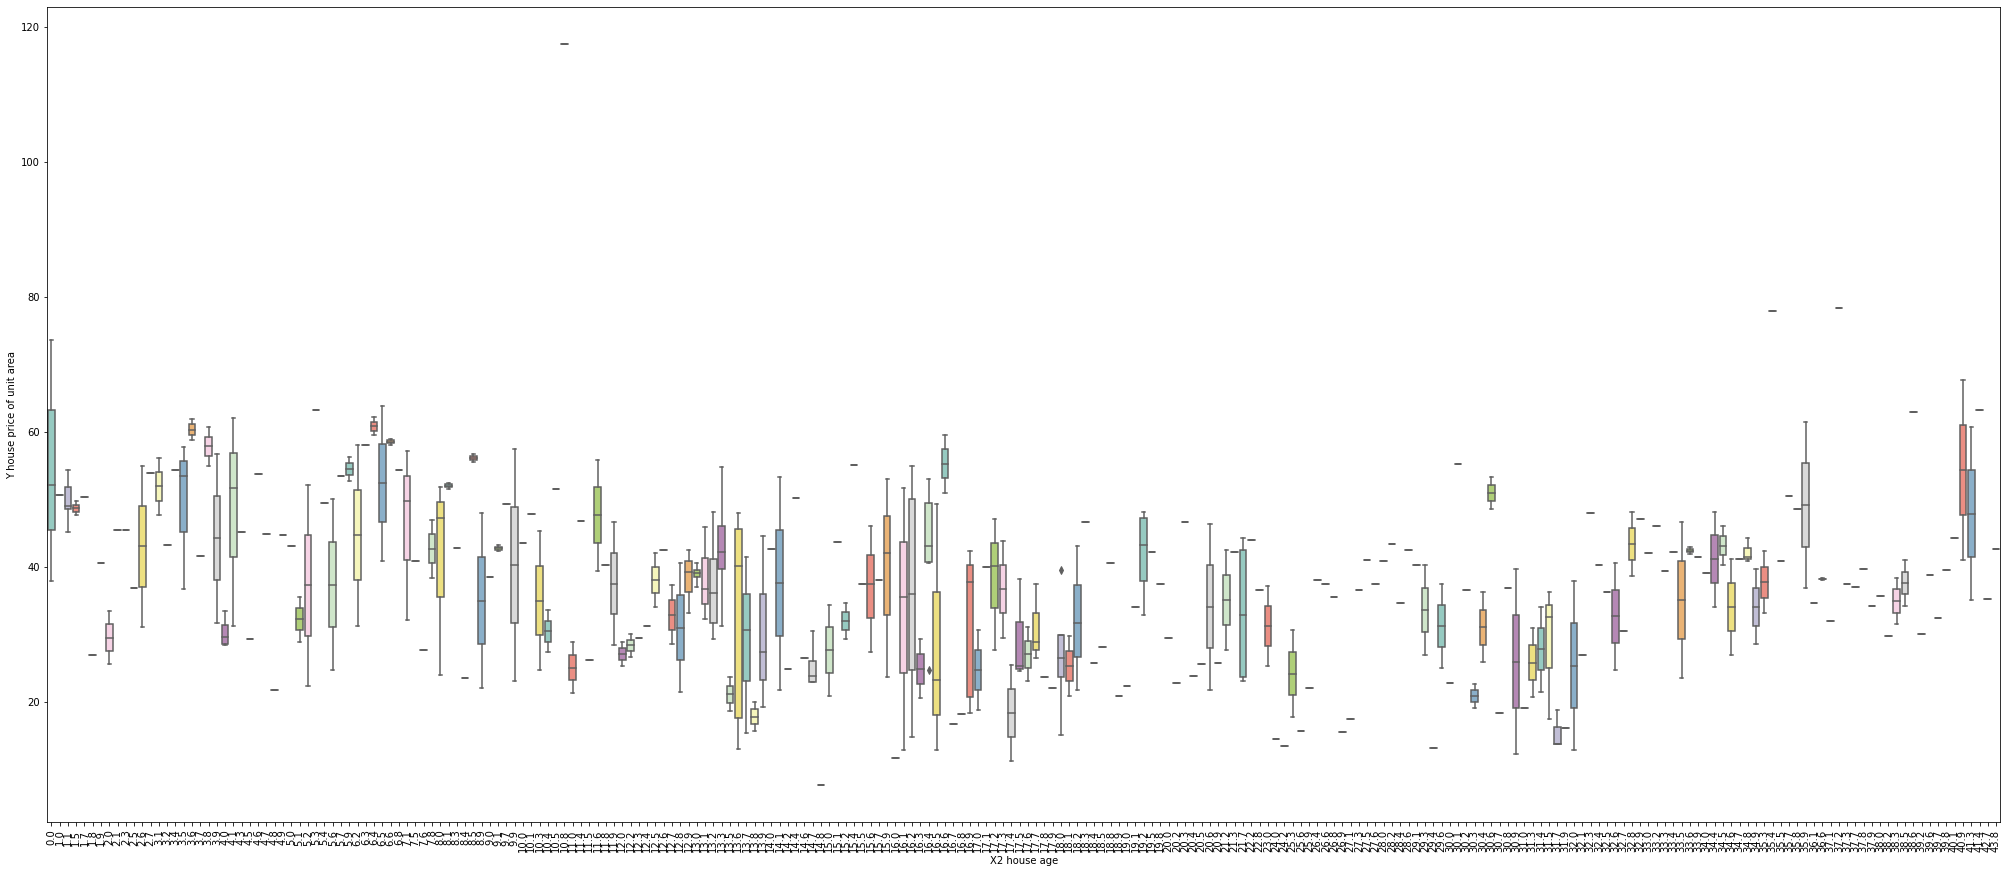

In [47]:
plt.figure(figsize=(35, 15))
plt.xticks(rotation=90)
sns.boxplot(x="X2 house age", y="Y house price of unit area",data=pandas_df, palette="Set3")

#### Correlation analysis

create the correlation matrix of all the columns and visualize using the heatmap

In [25]:
assembler1 = VectorAssembler(
                            inputCols= ["X1 transaction date", "X2 house age", "X3 distance to the nearest MRT station","X4 number of convenience stores","X5 latitude","X6 longitude",'Y house price of unit area'],
                            outputCol= "features")       # features is the name of output columns which combines all the columns

In [26]:
corr_input = assembler1.transform(df).select("features")            # A new column 'features' will be created along with the existing columns
                                            # features column will include all the values combined in one list

In [27]:
# correlation will be in Dense Matrix
from pyspark.ml.stat import Correlation
correlation = Correlation.corr(corr_input,"features","pearson").collect()[0][0]

# To convert Dense Matrix into DataFrame
rows = correlation.toArray().tolist()
df_new = spark.createDataFrame(rows,["X1 transaction date", "X2 house age", "X3 distance to the nearest MRT station","X4 number of convenience stores","X5 latitude","X6 longitude",'Y house price of unit area'])
df_new.show(10)

+--------------------+--------------------+--------------------------------------+-------------------------------+--------------------+--------------------+--------------------------+
| X1 transaction date|        X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|         X5 latitude|        X6 longitude|Y house price of unit area|
+--------------------+--------------------+--------------------------------------+-------------------------------+--------------------+--------------------+--------------------------+
|                 1.0|0.017548767356174215|                   0.06087995314209749|           0.009635444586543635|0.035057756205304484|-0.04108177780132841|       0.08749060640259809|
|0.017548767356174215|                 1.0|                  0.025622047362740943|            0.04959251292396377|0.054419901960116306|-0.04852005338536859|      -0.21056704627721695|
| 0.06087995314209749|0.025622047362740943|                                   1.

In [28]:
df_create = df_new.toDF("X1 transaction date", "X2 house age", "X3 distance to the nearest MRT station","X4 number of convenience stores","X5 latitude","X6 longitude",'Y house price of unit area')
pandas_df = df_create.toPandas()

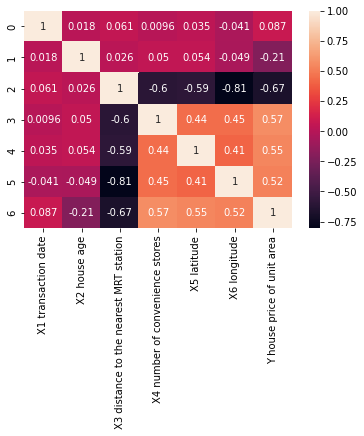

In [29]:
sns.heatmap(pandas_df,annot=True);

#### Normalization or standardization 

select the applicable features using vector assembler and apply scaling using `MinMaxScaler` from pyspark

Hint: [MinMaxScaler](https://spark.apache.org/docs/latest/ml-features#minmaxscaler)

#### Assemble the features

concatenate all the features into a single vector which can be further passed to the ML algorithm.

**Hint:** `VectorAssembler()`

In [30]:
from pyspark.ml.feature import MinMaxScaler
from pyspark.ml import Pipeline

assembler = VectorAssembler(
                            inputCols= ["X1 transaction date", "X2 house age", "X3 distance to the nearest MRT station","X4 number of convenience stores","X5 latitude","X6 longitude"],
                            outputCol= "features")       # features is the name of output columns which combines all the columns
scaler = MinMaxScaler(inputCol="features", outputCol="features_scaled")
pipeline = Pipeline(stages=[assembler, scaler])
scalerModel = pipeline.fit(df)
scaledData = scalerModel.transform(df)

### Feature Engineering (2 points)

In [31]:
scaledData.show(10)

+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+--------------------+--------------------+
| No|X1 transaction date|X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|X5 latitude|X6 longitude|Y house price of unit area|            features|     features_scaled|
+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+--------------------+--------------------+
|  1|           2012.917|        32.0|                              84.87882|                             10|   24.98298|   121.54024|                      37.9|[2012.917,32.0,84...|[0.27292576419208...|
|  2|           2012.917|        19.5|                              306.5947|                              9|   24.98034|   121.53951|                      42.2|[2012.917,19.5,30...|[0

In [32]:
scaledData.select("features_scaled").show(10, truncate= False)          # displays only the features_scaled column (which includes all other column values in a list)

+---------------------------------------------------------------------------------------------------------------------+
|features_scaled                                                                                                      |
+---------------------------------------------------------------------------------------------------------------------+
|[0.27292576419208986,0.7305936073059361,0.00951267162646579,1.0,0.616941347552139,0.7193228380417942]                |
|[0.27292576419208986,0.44520547945205485,0.043809390872388755,0.9,0.5849491032477332,0.7114513694199474]             |
|[0.9999999999999999,0.30365296803652975,0.0833150513098478,0.5,0.671231216674745,0.7588958378261307]                 |
|[0.9093886462881348,0.30365296803652975,0.0833150513098478,0.5,0.671231216674745,0.7588958378261307]                 |
|[0.18122270742373037,0.11415525114155252,0.05679908927803007,0.5,0.573194377120705,0.7431529005822838]               |
|[0.0,0.16210045662100458,0.332833347628

In [33]:
# Complete dataset is represented in 2 columns
final_data = scaledData.select("features_scaled",'Y house price of unit area') 

#### Feature selection and splitting the data

In [34]:
# Splitting the data in Train and Test set(70% training data, 30% testing data)
train_data,test_data = final_data.randomSplit([0.7,0.3])

In [35]:
train_data.describe().show()

+-------+--------------------------+
|summary|Y house price of unit area|
+-------+--------------------------+
|  count|                       285|
|   mean|          37.8985964912281|
| stddev|        13.692559848557378|
|    min|                      11.6|
|    max|                     117.5|
+-------+--------------------------+



In [36]:
test_data.describe().show()

+-------+--------------------------+
|summary|Y house price of unit area|
+-------+--------------------------+
|  count|                       129|
|   mean|         38.16046511627908|
| stddev|        13.465583552411559|
|    min|                       7.6|
|    max|                      73.6|
+-------+--------------------------+



### Train and Evaluate the model (2 points)

Using LinearRegression from `pyspark.ml` fit the data and find the coefficients and intercept

In [37]:
regressor = LinearRegression(featuresCol="features_scaled", labelCol="Y house price of unit area")

#Learn to fit the model from training set
model = regressor.fit(train_data)

Get the predictions and show the table along with actual data and predicted data

In [38]:
predict = model.transform(test_data)

predict.select(predict.columns[:]).show(10)

+--------------------+--------------------------+------------------+
|     features_scaled|Y house price of unit area|        prediction|
+--------------------+--------------------------+------------------+
|[0.0,0.0,0.025066...|                      37.9| 38.62091215918916|
|[0.0,0.0251141552...|                      51.8|45.624687555582675|
|[0.0,0.0342465753...|                      47.7|45.968461904632676|
|[0.0,0.0707762557...|                      47.7|42.866609058587315|
|[0.0,0.1278538812...|                      50.0| 48.37503195604161|
|[0.0,0.3561643835...|                      46.1|42.468009250092855|
|[0.0,0.4657534246...|                      23.8|26.203695411884443|
|[0.0,0.6940639269...|                      25.9|25.791306077149798|
|[0.0,0.7511415525...|                      47.1| 45.30286663621281|
|[0.0,0.7625570776...|                      42.2|36.632398937188825|
+--------------------+--------------------------+------------------+
only showing top 10 rows



Calculate the RMSE and $R^2$ of the model

In [39]:
metrics = model.evaluate(test_data)                             # Using evaluate method we can verify our model's performance

print('Mean absolute error: {}'.format(metrics.meanAbsoluteError))
print('Root mean squared error: {}'.format(metrics.rootMeanSquaredError))
print('R_squared value: {}'.format(metrics.r2))

Mean absolute error: 6.798489351475784
Root mean squared error: 8.811100849017306
R_squared value: 0.5684911306077758
